In [61]:
import pandas as pd
import requests
from io import StringIO

base_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv"
query = "?$where=year >= 2021&$limit=200000"
response = requests.get(base_url + query)

if response.status_code == 200:
    df_total = pd.read_csv(StringIO(response.text))
    
df_theft = df_total[df_total['primary_type'] == 'THEFT'].copy().reset_index(drop=True)
df_theft['date'] = pd.to_datetime(df_theft['date'])

df_theft['Hour'] = df_theft['date'].dt.hour
df_theft['DayOfWeek'] = df_theft['date'].dt.day_name()

df_theft[['date', 'primary_type', 'description', 'latitude', 'longitude']].head()


,date,primary_type,description,latitude,longitude
0,2026-05-19 00:00:00,THEFT,THEFT FROM MOTOR VEHICLE,41.820043,-87.697658
1,2026-05-19 00:00:00,THEFT,THEFT FROM MOTOR VEHICLE,41.920637,-87.697814
2,2026-05-19 00:00:00,THEFT,THEFT FROM MOTOR VEHICLE,42.016607,-87.675303
3,2026-05-19 00:00:00,THEFT,FROM BUILDING,41.708186,-87.625944
4,2026-05-18 23:00:00,THEFT,THEFT FROM MOTOR VEHICLE,41.785200,-87.712299


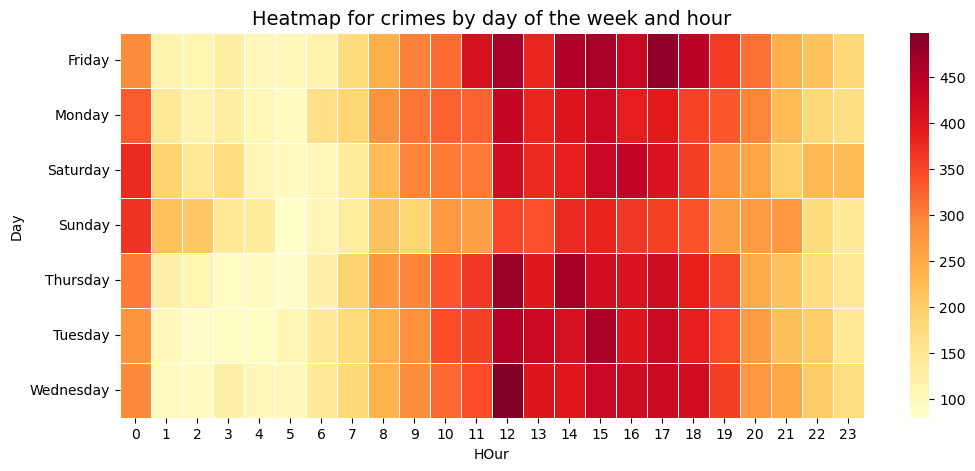

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_time = df_theft.groupby(['DayOfWeek', 'Hour']).size().unstack()

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_time, cmap="YlOrRd", linewidths=.5)
plt.title("Heatmap for crimes by day of the week and hour", fontsize=14)
plt.xlabel("HOur")
plt.ylabel("Day")
plt.show()

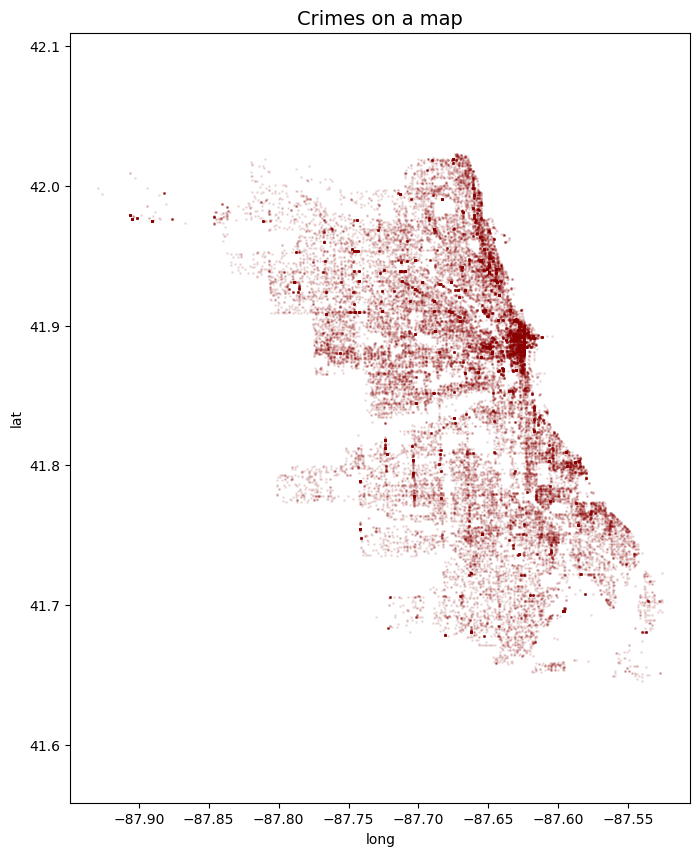

In [65]:
plt.figure(figsize=(8, 10))

plt.scatter(x=df_theft['longitude'], y=df_theft['latitude'], 
            alpha=0.1, s=1, color='darkred')

plt.title("Crimes on a map", fontsize=14)
plt.xlabel("long")
plt.ylabel("lat")

plt.axis('equal') 
plt.show()

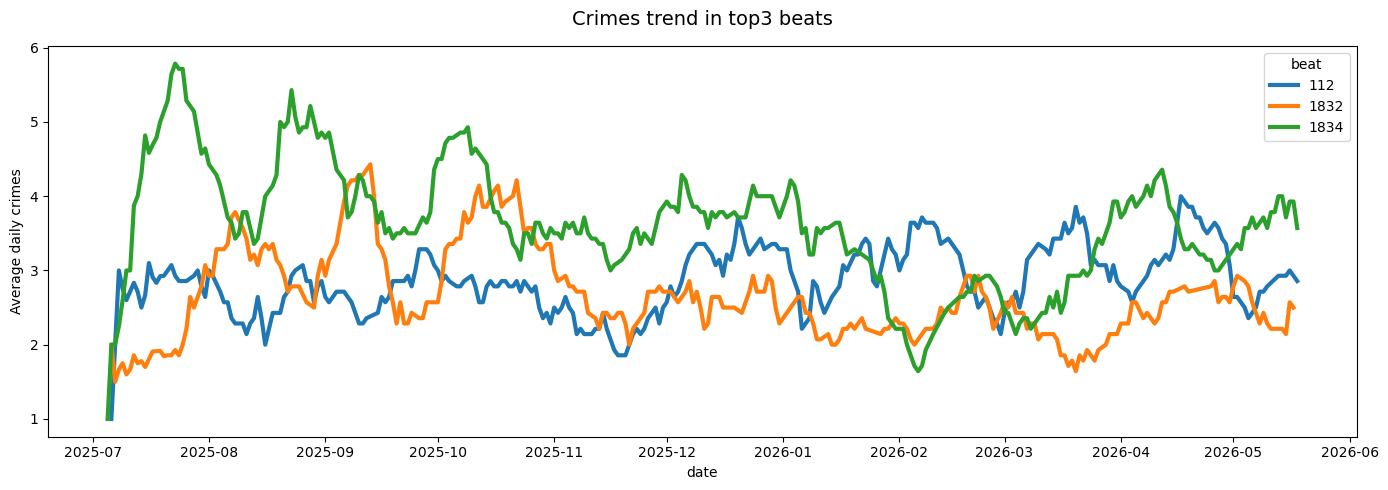

In [66]:
top_3_beats = df_theft['beat'].value_counts().nlargest(3).index

df_top3 = df_theft[df_theft['beat'].isin(top_3_beats)].copy()
df_top3['date_only'] = df_top3['date'].dt.date

daily_beats = df_top3.groupby(['date_only', 'beat']).size().reset_index(name='daily_crimes')
daily_beats = daily_beats.sort_values(['beat', 'date_only'])
daily_beats['smoothed_crimes'] = daily_beats.groupby('beat')['daily_crimes'].transform(lambda x: x.rolling(window=14, min_periods=1).mean())

plt.figure(figsize=(14, 5), facecolor='white')

sns.lineplot(data=daily_beats, x='date_only', y='smoothed_crimes', 
             hue='beat', palette='tab10', lw=3)
plt.title("Crimes trend in top3 beats", fontsize=14, pad=15)
plt.xlabel("date")
plt.ylabel("Average daily crimes")
plt.legend(title='beat')

plt.tight_layout()
plt.show()

In [67]:
import folium
from folium.plugins import HeatMap
df_map = df_theft.dropna(subset=['latitude', 'longitude'])

m = folium.Map(location=[41.8781, -87.6298], zoom_start=11, tiles='CartoDB Positron')

heat_data = [[row['latitude'], row['longitude']] for index, row in df_map.iterrows()]
HeatMap(heat_data, radius=13, blur=15).add_to(m)

m.save("chicago_theft_heatmap.html")

C:\Users\pzbzb\AppData\Local\Temp\ipykernel_31564\1288080188.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='description',


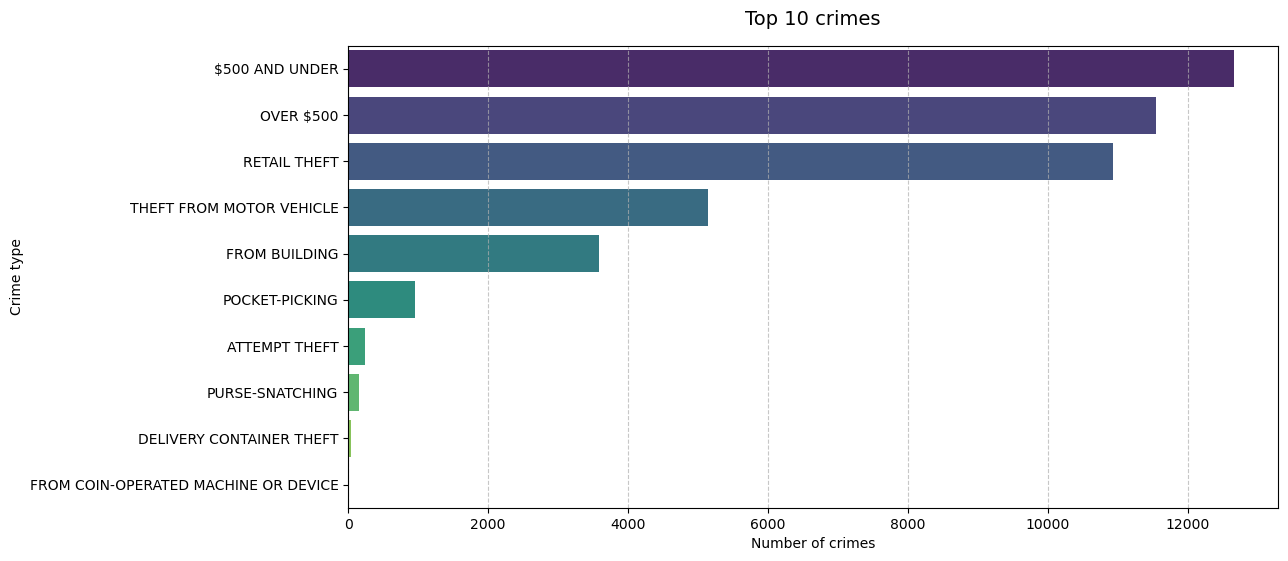

In [68]:
plt.figure(figsize=(12, 6), facecolor='white')
sns.countplot(y='description', 
              data=df_theft, 
              order=df_theft['description'].value_counts().iloc[:10].index, 
              palette='viridis')
plt.title("Top 10 crimes", fontsize=14, pad=15)
plt.xlabel("Number of crimes")
plt.ylabel("Crime type")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

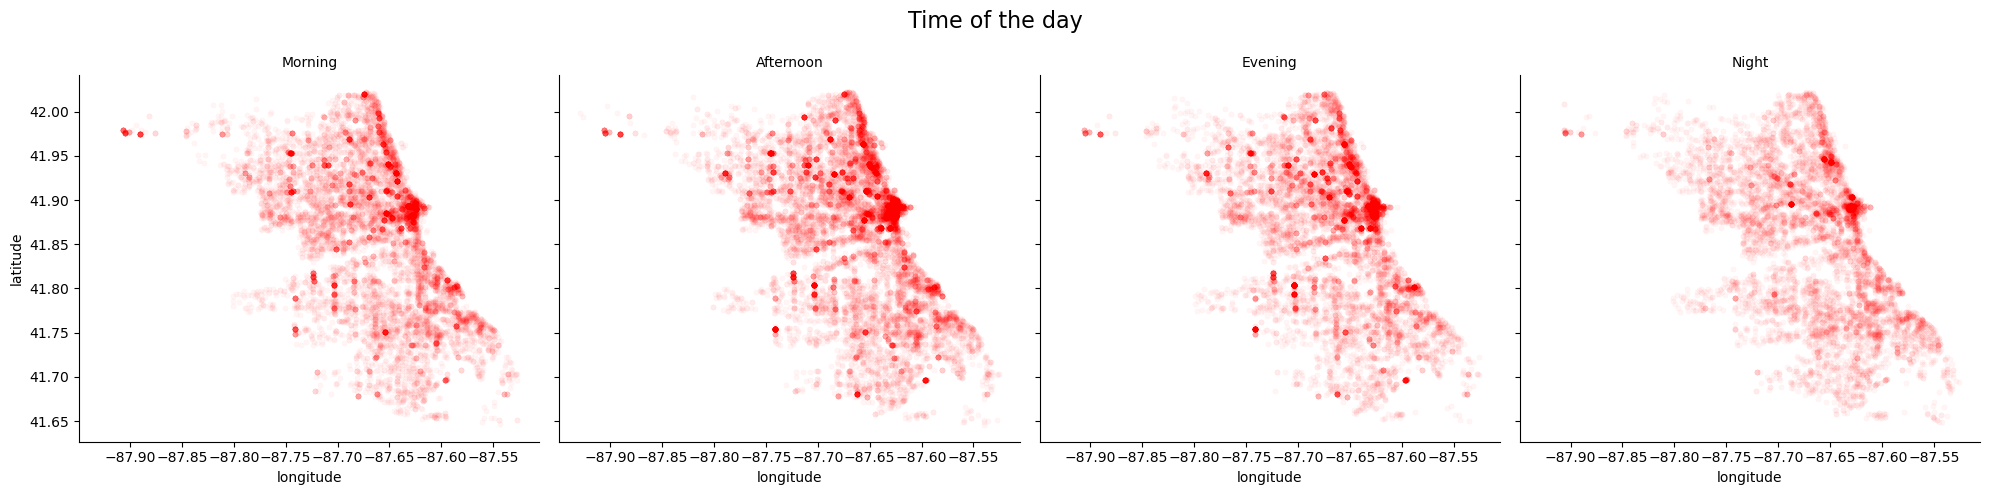

In [ ]:
def get_time_of_day(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 22: return 'Evening'
    else: return 'Night'

df_theft['time_of_day'] = df_theft['Hour'].apply(get_time_of_day)
order = ['Morning', 'Afternoon', 'Evening', 'Night']

g = sns.relplot(
    data=df_theft.dropna(subset=['latitude', 'longitude']),
    x="longitude", 
    y="latitude",
    col="time_of_day",
    col_order=order,
    col_wrap=4,
    kind="scatter",
    alpha=0.04,
    color="red",
    s=15, 
    edgecolor=None,
    height=5)

g.set_titles("{col_name}")
g.fig.suptitle('Time of the day', fontsize=16)
plt.subplots_adjust(top=0.85) 
plt.show()

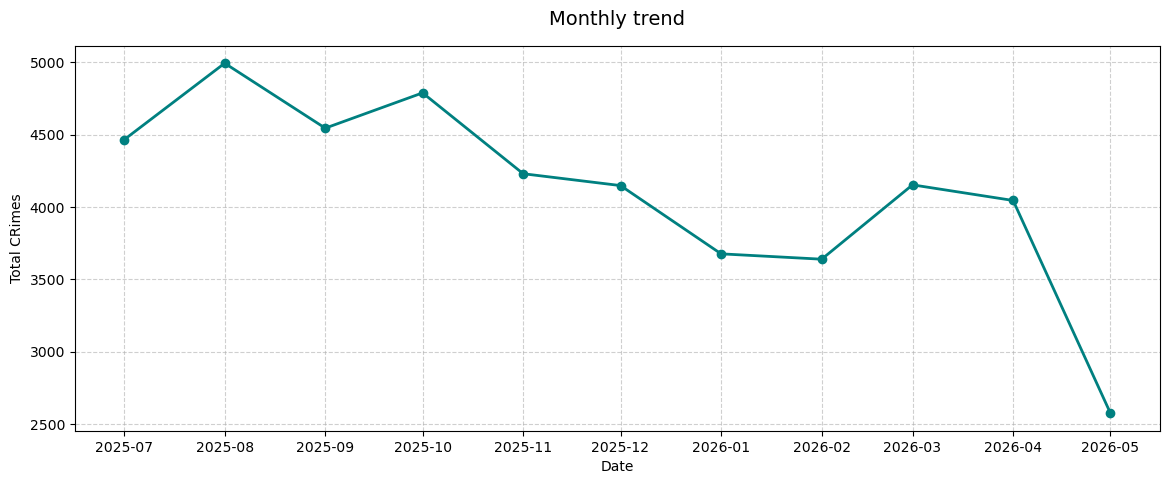

In [77]:
df_theft['year_month'] = df_theft['date'].dt.to_period('M')
monthly_crimes = df_theft.groupby('year_month').size()

plt.figure(figsize=(14, 5), facecolor='white')
monthly_crimes.index = monthly_crimes.index.to_timestamp()
plt.plot(monthly_crimes.index, monthly_crimes.values, marker='o', linestyle='-', color='teal', lw=2)

plt.title("Monthly trend", fontsize=14, pad=15)
plt.xlabel("Date")
plt.ylabel("Total CRimes")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()